# ResonantSTFT behavior under three input regimes

`ResonantSTFT` is a layer of two-compartment oscillators: each channel runs at its own trainable `(λ, ω_f)` and reports the phase of its driven signal compartment relative to a free-running reference at the same `ω_f`. After integration the per-channel output is re-encoded at the network's shared carrier `ω_out` so downstream phase-locked layers see a consistent frame.

Three regimes worth confirming:

1. **Noise** — all frequency components present, no channel resonates, magnitudes stay near zero and output phases scatter uniformly.
2. **Single tone** — only the matching channel resonates: large magnitude, constant phase offset. Off-resonance channels beat at `ω_in − ω_f`, so their output phase precesses linearly.
3. **Frequency sweep (chirp)** — each channel briefly resonates as the instantaneous frequency sweeps past `ω_f`, producing a diagonal stripe in the magnitude heatmap.

Across all three the **interference magnitude `|Z|` is the resonance quality**. Sub-threshold magnitude means the channel's phase is meaningless. The layer's default activation — `soft_normalize_to_unit_circle` (SLERP between `1+0im` and `z/|z|` via a sigmoid on `|z|`) — gates weak channels back to a silent reference, leaving phase information only on synchronized channels. **The SLERP thresholds `r_lo` and `r_hi` are per-channel trainable parameters** stored in the layer (as `log_r_lo, log_r_gap` for positivity), so the gate adapts to whatever magnitude scale training data actually produces.

To visualize the raw quantities (`|Z|`, raw phase) underneath the SLERP gate, we instantiate the layer with the legacy `identity` activation (`ResonantSTFT(1 => n_freqs, identity)`), which skips the SLERP step entirely and exposes the raw complex output. The default constructor `ResonantSTFT(1 => n_freqs)` (no activation arg) gives the new trainable-SLERP behavior — demonstrated in the final section.

Why `ω_out = 2π` makes the static frame easy to read: at integer sample times `exp(i·2π·n) = 1`, so the freq-shift step exactly cancels each channel's own carrier `ω_f`. A matching channel's output sits at a constant phase; a mismatched channel's output rotates at the *beat* `ω_in − ω_f`.

In [1]:
using Pkg
Pkg.activate("..")

  Activating project at `~/code/PhasorNetworks.jl`


In [2]:
using Random: Xoshiro
using Lux
using Plots
using Statistics: mean

In [3]:
include("../src/PhasorNetworks.jl")

Main.PhasorNetworks

In [4]:
using .PhasorNetworks

## Setup

`n_freqs = 32` analysis channels spread linearly over `ω ∈ [0.5, 2.5]` rad/step.
Sequence length `L = 256` is well past the resonance settling time (`τ ≈ 1/|λ| = 10` steps).
Input amplitude scaled by `|λ|` so steady-state resonant magnitude is `≈ 1` — picks reasonable SLERP thresholds.

In [13]:
const L         = 256
const n_freqs   = 64
const omega_lo  = 0.5f0
const omega_hi  = 2.5f0
const λ         = -0.1f0
const omega_out = Float32(2π)
const input_amp = abs(λ)              # peak resonant |Z| ≈ 1

ωs = Float32.(range(omega_lo, omega_hi; length=n_freqs))
ts = Float32.(0:L-1);

## Helpers

`run_stft` runs the real `ResonantSTFT` 3D-Complex dispatch with the legacy `identity` activation — this skips the trainable-SLERP step and exposes the raw complex `Z` so we can plot magnitude (interference strength) and angle (phase) directly. Weights are forced to all-ones so every channel sees the same input; only `(λ, ω)` differ across channels.

In [14]:
function run_stft(signal::AbstractVector{<:Complex})
    layer = ResonantSTFT(1 => n_freqs, identity;
                        omega_lo=omega_lo, omega_hi=omega_hi,
                        omega_out=omega_out,
                        init_log_neg_lambda=log(-λ))
    ps, st = Lux.setup(Xoshiro(0), layer)
    ps = (weight         = ones(Float32, n_freqs, 1),
          log_neg_lambda = fill(Float32(log(-λ)), n_freqs),
          omega          = ωs)
    x = reshape(ComplexF32.(signal) .* input_amp, 1, L, 1)
    Z, _ = layer(x, ps, st)
    return Z[:, :, 1]               # (n_freqs, L)
end

run_stft (generic function with 1 method)

In [15]:
noise_signal(rng) = ComplexF32.(randn(rng, Float32, L) .+ 1.0f0im .* randn(rng, Float32, L))

single_tone(ω) = ComplexF32.(exp.(1.0f0im .* Float32(ω) .* ts))

function chirp(ω0, ω1)
    # Linear instantaneous frequency from ω0 → ω1 over L steps.
    α = (Float32(ω1) - Float32(ω0)) / Float32(L)
    φ = Float32(ω0) .* ts .+ 0.5f0 .* α .* ts.^2
    return ComplexF32.(exp.(1.0f0im .* φ))
end

chirp (generic function with 1 method)

In [16]:
function plot_case(name::String, Z::AbstractMatrix{<:Complex};
                   r_lo::Real = 0.1f0, r_hi::Real = 0.6f0)
    phase_raw   = Float32.(angle.(Z) ./ Float32(π))
    mag         = abs.(Z)
    Z_slerp     = soft_normalize_to_unit_circle(Z; r_lo=Float32(r_lo), r_hi=Float32(r_hi))
    phase_slerp = Float32.(angle.(Z_slerp) ./ Float32(π))

    common = (xlabel="time step", ylabel="channel ω (rad/step)")

    p_mag = heatmap(ts, ωs, mag;
                    c=:viridis, title="$name — |Z| (interference strength)",
                    common...)
    p_phr = heatmap(ts, ωs, phase_raw;
                    c=:hsv, clims=(-1, 1),
                    title="$name — raw phase  (arg(Z) / π)",
                    common...)
    p_phs = heatmap(ts, ωs, phase_slerp;
                    c=:hsv, clims=(-1, 1),
                    title="$name — SLERP phase  (r_lo=$(r_lo), r_hi=$(r_hi))",
                    common...)
    plot(p_mag, p_phr, p_phs; layout=(3, 1), size=(820, 900))
end

plot_case (generic function with 1 method)

## Case 1 — White noise

Complex Gaussian input. No frequency component dominates, so no channel locks. Expect: small `|Z|` everywhere, raw phase scattered, SLERP-thresholded phase collapses to `0` (silent reference).

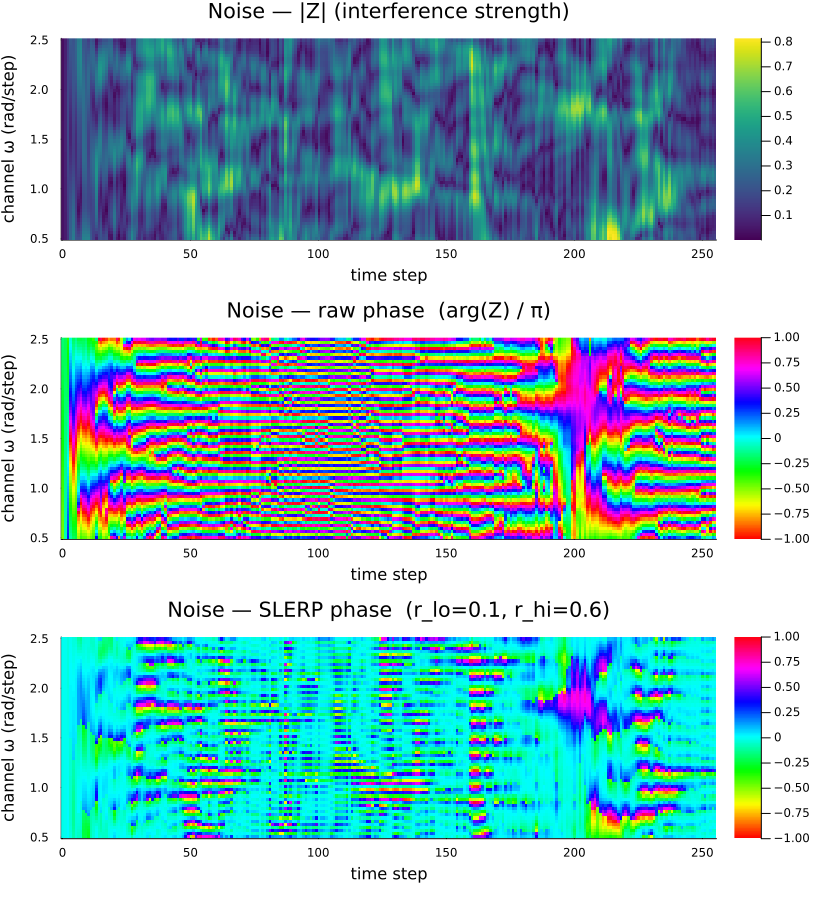

In [17]:
Z_noise = run_stft(noise_signal(Xoshiro(1)))
plot_case("Noise", Z_noise)

## Case 2 — Single tone

Pure complex exponential at `ω_test = 1.5` rad/step (mid-band). Expect:
- A horizontal bright stripe in `|Z|` at the channel whose `ω_f ≈ ω_test`.
- A flat (constant) phase along that channel; off-resonance channels show diagonal stripes (phase rotating at the beat `ω_test − ω_f`).
- SLERP gates off the off-resonance channels — the resonant channel retains its constant phase.

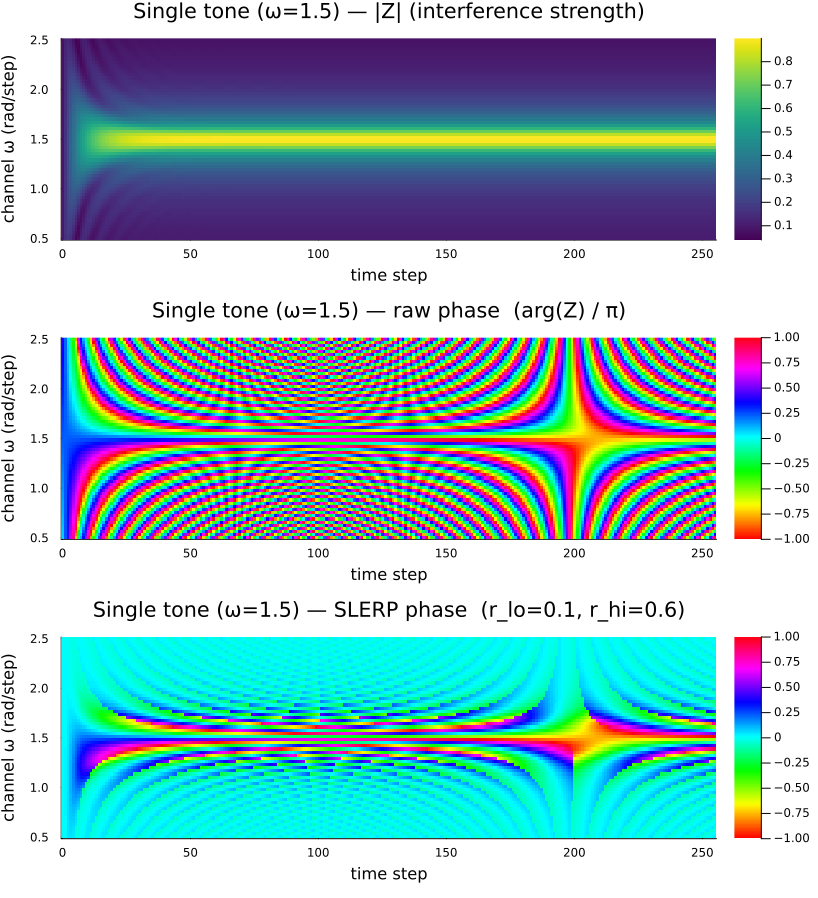

In [18]:
const ω_test = 1.5f0
Z_tone = run_stft(single_tone(ω_test))
plot_case("Single tone (ω=$(ω_test))", Z_tone)

Steady-state magnitude vs channel ω confirms the Lorentzian resonance peak at `ω_f ≈ ω_test`:

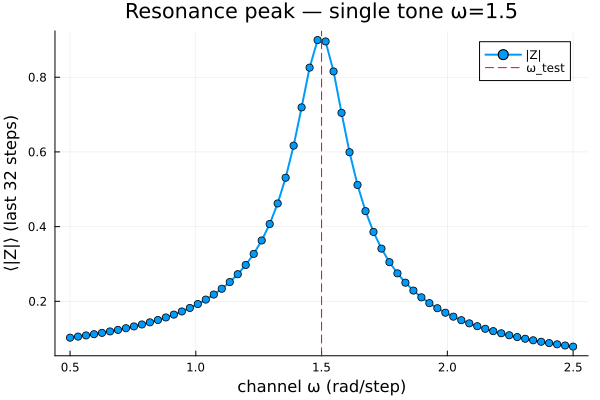

In [19]:
ss_mag = vec(mean(abs.(Z_tone[:, end-31:end]); dims=2))
plot(ωs, ss_mag;
     marker=:circle, lw=2,
     xlabel="channel ω (rad/step)", ylabel="⟨|Z|⟩ (last 32 steps)",
     title="Resonance peak — single tone ω=$(ω_test)",
     label="|Z|")
vline!([ω_test]; ls=:dash, c=:red, label="ω_test")

## Case 3 — Frequency sweep (chirp)

Linear chirp from `ω_lo` to `ω_hi` over the full sequence. Expect a **diagonal stripe** in `|Z|`: each channel resonates only while the instantaneous frequency passes through its `ω_f`. The raw-phase plot shows transient phase-lock along the stripe and beating elsewhere. SLERP cleans this to a thin diagonal of phase-meaningful samples.

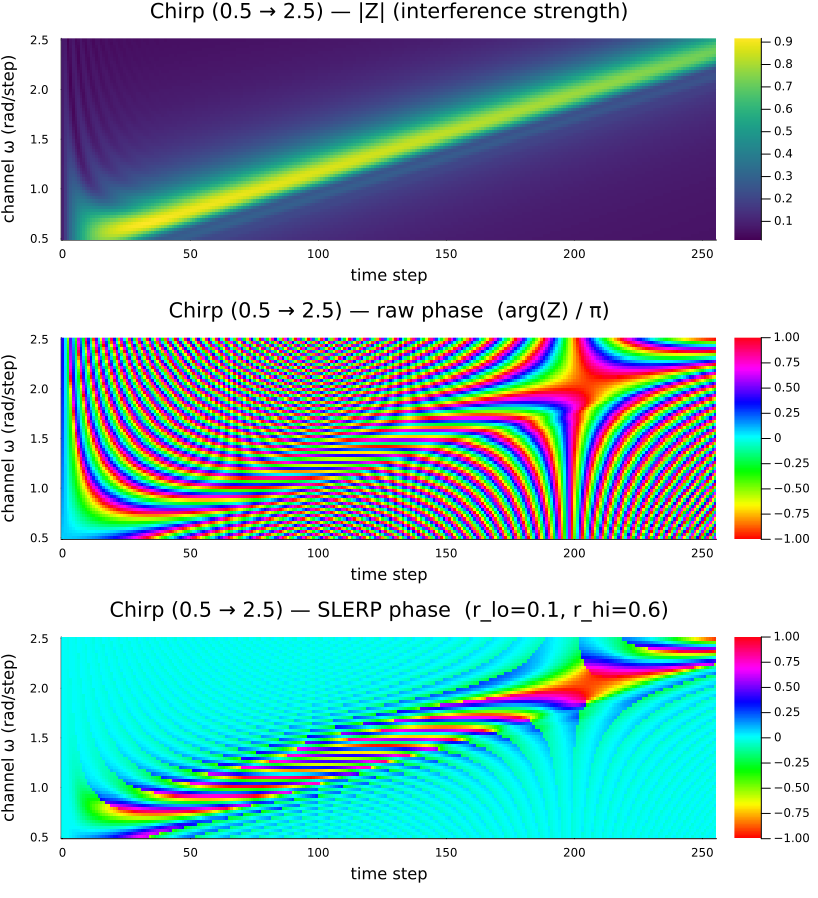

In [20]:
Z_chirp = run_stft(chirp(omega_lo, omega_hi))
plot_case("Chirp ($(omega_lo) → $(omega_hi))", Z_chirp)

## Discussion — SLERP as a magnitude-aware phase gate

The previous default activation, `normalize_to_unit_circle(z; ε = 1e-8)`, divided by `sqrt(|z|² + ε)`. For `|z| ≫ √ε` the output sat on the unit circle and faithfully carried the phase; for `|z| ≪ √ε` the output's *magnitude* shrank but its phase was still the raw `arg(z)` (which, on a near-zero channel, is dominated by integration noise). Downstream phase-locked layers then treated that noisy phase as data.

`soft_normalize_to_unit_circle` (SLERP) instead **interpolates the phase** between `0` (silent reference) and `arg(z)` via a sigmoid on `|z|`. The output sits *exactly* on the unit circle regardless of input magnitude, but a sub-threshold channel reports phase `0` rather than noise. This matches the picture above:

- **Noise**: every channel should be silent. SLERP collapses most of the plane to the reference and leaves only momentary high-magnitude bursts visible.
- **Single tone**: the resonant channel keeps its constant phase; the "x-shaped" interference patterns radiating off-resonance (visible in the raw-phase plot — slow beats near the peak, fast beats far away) are gated to silent. The narrow remaining stripe is the band of channels actually phase-locked to the input.
- **Chirp**: a thin diagonal of phase-meaningful samples follows the instantaneous frequency; everything else is silenced.

**Threshold tuning matters.** With the construction defaults `r_lo = 0.1`, `r_hi = 0.6` and our input scaling (peak resonant `|Z| ≈ 0.87`, noise mean `|Z| ≈ 0.26`), the noise case lands squarely in the sigmoid transition — which is why the noise SLERP plot still shows scattered phase bursts rather than collapsing entirely to silence. The single-tone and chirp cases work cleanly because their resonant channels sit well above `r_hi` and their off-resonance channels well below `r_lo`. Picking `r_lo` near the noise floor and `r_hi` near (peak / 2) gives the cleanest gating for a given layer's magnitude scale.

Because `r_lo` and `r_hi` are **now trainable per-channel** (stored as `log_r_lo, log_r_gap` in `params`, parameterized so `r_hi > r_lo > 0` is always preserved), each channel can co-tune its own gate against its own dynamics during training — channels with strong resonance (small `|λ|`, dense data spectrum) can adopt high `r_hi`, while quiet channels can pull `r_lo` down to keep weak signals alive. The closing cells below verify the default constructor produces this behavior and inspect the initial gate.

## Trainable-SLERP default layer — sanity check

Instantiate `ResonantSTFT` with **no** activation argument (new default), inspect its parameter set, and apply it to the three test signals. The output should be (i) unit-magnitude everywhere and (ii) phase-meaningful only on synchronized channels — i.e. visually consistent with the "SLERP phase" panels above.

In [ ]:
function run_stft_default(signal::AbstractVector{<:Complex})
    # No activation arg → trainable SLERP with init_r_lo / init_r_hi
    layer = ResonantSTFT(1 => n_freqs;
                        omega_lo=omega_lo, omega_hi=omega_hi,
                        omega_out=omega_out,
                        init_log_neg_lambda=log(-λ),
                        init_r_lo=0.1f0, init_r_hi=0.6f0)
    ps, st = Lux.setup(Xoshiro(0), layer)
    ps = merge(ps, (weight         = ones(Float32, n_freqs, 1),
                    log_neg_lambda = fill(Float32(log(-λ)), n_freqs),
                    omega          = ωs))
    x = reshape(ComplexF32.(signal) .* input_amp, 1, L, 1)
    Y, _ = layer(x, ps, st)
    return Y[:, :, 1], ps
end

Y_tone, ps_default = run_stft_default(single_tone(ω_test))
println("Default layer params: ", keys(ps_default))
println("  init r_lo  = ", exp(ps_default.log_r_lo[1]))
println("  init r_gap = ", exp(ps_default.log_r_gap[1]),
        "  → r_hi = ", exp(ps_default.log_r_lo[1]) + exp(ps_default.log_r_gap[1]))
println("  |Y| range  = [", minimum(abs.(Y_tone)), ", ", maximum(abs.(Y_tone)), "]  (must be ≈ 1)")

In [ ]:
Y_noise, _  = run_stft_default(noise_signal(Xoshiro(1)))
Y_chirp, _  = run_stft_default(chirp(omega_lo, omega_hi))

function plot_default_phase(name, Y)
    phase = Float32.(angle.(Y) ./ Float32(π))
    heatmap(ts, ωs, phase; c=:hsv, clims=(-1, 1),
            xlabel="time step", ylabel="channel ω (rad/step)",
            title="$name — default layer (trainable SLERP) phase / π")
end

plot(plot_default_phase("Noise", Y_noise),
     plot_default_phase("Single tone (ω=$(ω_test))", Y_tone),
     plot_default_phase("Chirp ($(omega_lo) → $(omega_hi))", Y_chirp);
     layout=(3,1), size=(820, 900))